# Derivada

A derivada de uma função y = f(x) em um ponto x = x0, é igual ao valor da tangente trigonométrica do ângulo formado pela tangente geométrica à curva representativa de y=f(x), no ponto x = x0, ou seja, a derivada é o coeficiente angular da reta tangente ao gráfico da função no ponto x0.

## Método *Forward* e *backward*

 <img src='Derivada_AvancarRetroceder.png' /></a>

In [5]:
import numpy as np
import pylab as plt

### Exemplo:    $y = x^2 - 5x + 6$  

In [6]:
y = lambda x: x**2 - 5*x + 6

In [7]:
#Método Avancar

def derivada_avancar(funcao, a, h=0.01):
    return (funcao(a+h)-funcao(a))/h

In [8]:
derivada_avancar(y,0)

-4.9900000000000055

In [9]:
#Método Retroceder

def derivada_retroceder(funcao, a, h=0.01):
    return (funcao(a)-funcao(a-h))/h

In [10]:
derivada_retroceder(y,0)

-5.009999999999959

## Método Central

 <img src='Derivada_Central.png' /></a>

In [11]:
#Método Central

def derivada_central(funcao, a, h=0.01):
    return (funcao(a+h)-funcao(a-h))/(2*h)

In [12]:
derivada_central(y,0)

-4.999999999999982

## Gráfico da deriva da função $y = x^2 - 5x + 6$ : 
## $y ' = 2x - 5$  

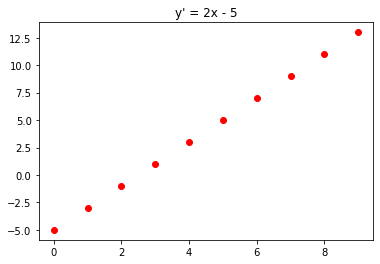

In [13]:
dy=np.empty(10)

for i in range(0,10):
    dy[i]=derivada_central(y,i)
    plt.plot(i,dy[i],'ro')

plt.title("y' = 2x - 5")
plt.show()


## Derivada de dados

Um exemplo típico é a função velocidade que representa a taxa de variação (derivada) da função espaço. Do mesmo modo, a função aceleração é a derivada da função velocidade.

In [14]:
import numpy as np
import pylab as plt

tempo,velocidade = np.loadtxt('velocities.txt',unpack=True)

#aceleração = d(velocidade)/dt

N = len(tempo)
aceleracao = np.empty(N)

# Métdodo Avançar
aceleracao[0] = (velocidade[1]-velocidade[0])/(tempo[1]-tempo[0])

# Método Central
for i in range (1,N-1):
    aceleracao[i] = (velocidade[i+1]-velocidade[i-1])/((tempo[i+1]-tempo[i-1])*2)

# Método Retroceder
aceleracao[N-1] = (velocidade[N-1]-velocidade[N-2])/(tempo[N-1]-tempo[N-2])

## Gráfico dos dados

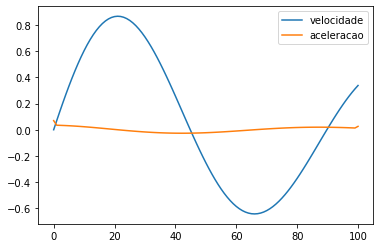

In [15]:
plt.plot(tempo, velocidade, label = 'velocidade')
plt.plot(tempo, aceleracao, label = 'aceleracao')
plt.legend()
plt.show()

## Derivada de Segunda Ordem

A derivada de segunda ordem de uma função é simplesmente a derivada da derivada da função.

 <img src='Derivada_Segunda.png' /></a>


In [16]:
# Derivada de Segunda Ordem

def derivada_segunda(funcao, a, h=0.01):
    return (funcao(a+h)-2*funcao(a)+funcao(a-h))/(h**2)

### Deriva de Segunda ordem da função $y = x^2 - 5x + 6$ : 
### $y ' = 2x - 5$
### $y'' = 2$

In [17]:
print(derivada_segunda(y,0))

1.9999999999953388


## Derivada Parcial

Uma derivada parcial de uma função de várias variáveis é a sua derivada com respeito a uma daquelas variáveis, com as outras variáveis mantidas constantes. 

 <img src='Derivada_parcial1.png' /></a>


In [18]:
# Derivada Parcial

def derivada_parcial(funcao,x,y, h=0.01):
    return (funcao(x+h/2,y+h/2)-f(x-h/2,y+h/2)-f(x+h/2,y-h/2)+f(x-h/2,y-h/2))/(h**2)

### Exemplo:

### $f(x,y) = x * sen(y) $

In [19]:
f = lambda x,y: x*np.sin(y)

In [21]:
# Derivada com relação a y: x.cos*y)
# Derivada com relação a x: sen(y)

d_parcial = derivada_parcial(f,20,np.pi/4)

print(d_parcial)

0.7071038349337755


In [3]:
# Fiz alguns execícios para treinar
#
#Começamos carrendo a biblioteca SymPy:
from sympy import *
init_printing()
var('x,y')

In [6]:
#Para fixar as ideias,continuar com a mesma função:

#f(x)=(x3−3x+2)e−x/4−1

f = Lambda(x, (x**3 - 3*x + 2)*exp(-x/4) - 1)
f

In [7]:
# Derivadas
# Podemos usar o SymPy para computarmos a derivada da função

# f′=df/dx

# Para tanto, usamos a função diff:

diff(f(x), x)

In [8]:
# Para avaliar a derivada em um ponto, por exemplo, para calcular  f′(1) , digitamos:
diff(f(x),x).subs(x,1)

In [9]:
# Também, podemos definir a função derivada de  f  com o seguinte código:
fl = Lambda(x, diff(f(x), x))
fl

In [10]:
# Com isso,  f′(1)  pode ser computada com:
fl(1)

In [13]:
# Reta Tangente
# Aqui, vamos ver como computar a reta tangente ao gráfico da função  f  no ponto  x0=−12 . Lembremos que tal reta tangente tem equação:

# y=f′(x0)(x−x0)+f(x0) .

# Assim sendo, podemos definir a função affim cujo gráfico é a reta tangente com o seguinte comando:

In [14]:
x0 = -1/2
r = Lambda(x, fl(x0)*(x-x0) + f(x0))
r

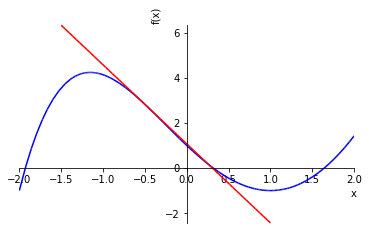

In [16]:
%matplotlib inline
p = plot(f(x), (x,-2,2), line_color='blue', show=False)
q = plot(r(x), (x,-1.5,1), line_color='red', show=False)
p.extend(q)
p.show()

In [17]:
# Derivadas de ordem mais altas
# Similarmente a derivadas de primeira ordem, as derivadas de ordem mais alta podem ser obtidas com a função diff. Por exemplo, para computarmos

# f′′=d2f/dx2 
# digitamos:
diff(f(x), x, 2)

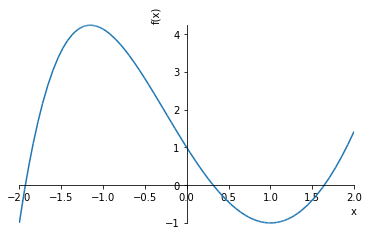

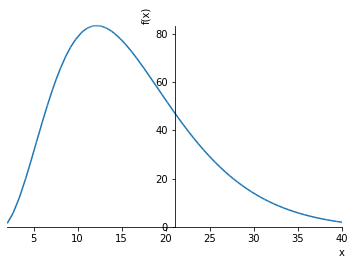

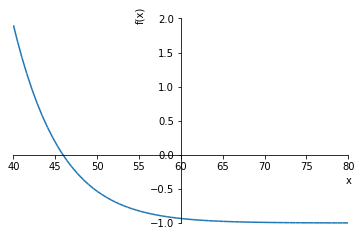

In [18]:
# Máximos e Mínimos Locais
# Agora, vamos ver como podemos usar o que aprendemos até aqui para resolver problemas de máximos e mínimos. Nosso objetivo será encontrar e determinar os pontos de máximos e mínimos locais da função  f . Para tanto, vamos usar o teste da segunda derivada.

# Comecemos lembrando do gráfico de  f :

plot(f(x), (x,-2,2))
plot(f(x), (x,2,40))
plot(f(x), (x,40,80))


In [19]:
# Observando os gráficos, podemos inferir que  f  tem máximos locais próximos a  x=−1  e  x=10  e um mínimo local próximo do ponto  x=1 . Logo, podemos usar estes valores como parâmetro da função nsolve para resolvermos

# f′(x)=0 .

# Computamos:

In [20]:
#ponto crítico próx. de x=-1
x1 = nsolve(fl(x), x, -1)
x1

In [21]:
#ponto crítico próx. de x=1
x2 = nsolve(fl(x), x, 1)
x2

In [22]:
#ponto crítico próx. de x=10
x3 = nsolve(fl(x), x, 10)
x3

In [24]:
# Ok. Acamos de encontrar os pontos críticos de  f(x)  (podem haver outros pontos críticos?). Por inspesão gráfica, vemos que  x1≈−1,15  e  x3≈12,15  são os pontos de máximos locais de  f(x) , com  x3  ponto de máximo global? O ponto  x2=1  é ponto de mínimo local?

# Podemos responder parcialmente estas questões com o teste da segunda derivada. Vejamos:

# f''

fll = Lambda(x, diff(f(x), x, 2))
fll

In [ ]:
fll(x1)

In [27]:
fll(x2)

In [28]:
fll(x3)

In [ ]:
# Logo, pelo teste da segunda derivada, confirmamos que  x1≈−1,15  e  x3≈12,15  são os pontos de máximos locais e  x2=1  é ponto de mínimo local. As demais questões em aberto ficam de exercício!